<a href="https://colab.research.google.com/github/Maryam1597/Applieddatascience1/blob/main/MARYAM_FYP_ASD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Autism Spectrum Disorder (ASD) Traits in Adults Using Behavioral and Demographic Indicators**

# **Library Installation And Import**

## **Install Required Libraries**

In [ ]:

!pip install ucimlrepo



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# SHAP library for model explainability
import shap

# **DATASET LOADING**

In [ ]:
# Fetch dataset
autism_screening_adult = fetch_ucirepo(id=426)

# Features and target
X = autism_screening_adult.data.features
y = autism_screening_adult.data.targets

# Combine for EDA
df = pd.concat([X, y], axis=1)

# Quick checks
print(df.shape)
df.head()


(704, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jaundice,family_pdd,country_of_res,used_app_before,result,age_desc,relation,class
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,NaN,no,no,Egypt,no,2,'18 and more',NaN,NO


# **INITIAL DATA EXPLORATION**

In [ ]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         704 non-null    int64  
 1   A2_Score         704 non-null    int64  
 2   A3_Score         704 non-null    int64  
 3   A4_Score         704 non-null    int64  
 4   A5_Score         704 non-null    int64  
 5   A6_Score         704 non-null    int64  
 6   A7_Score         704 non-null    int64  
 7   A8_Score         704 non-null    int64  
 8   A9_Score         704 non-null    int64  
 9   A10_Score        704 non-null    int64  
 10  age              702 non-null    float64
 11  gender           704 non-null    object 
 12  ethnicity        609 non-null    object 
 13  jaundice         704 non-null    object 
 14  family_pdd       704 non-null    object 
 15  country_of_res   704 non-null    object 
 16  used_app_before  704 non-null    object 
 17  result          

A1_Score            0
A2_Score            0
A3_Score            0
A4_Score            0
A5_Score            0
A6_Score            0
A7_Score            0
A8_Score            0
A9_Score            0
A10_Score           0
age                 2
gender              0
ethnicity          95
jaundice            0
family_pdd          0
country_of_res      0
used_app_before     0
result              0
age_desc            0
relation           95
class               0
dtype: int64

# **Exploratory Data Analysis**

## **Target Variable Distribution (Class Imbalance)**

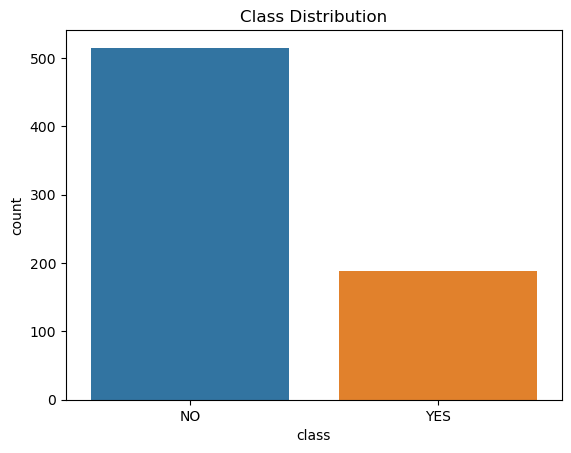

In [ ]:
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.show()


## **Correlation Matrix (Numerical Features)**

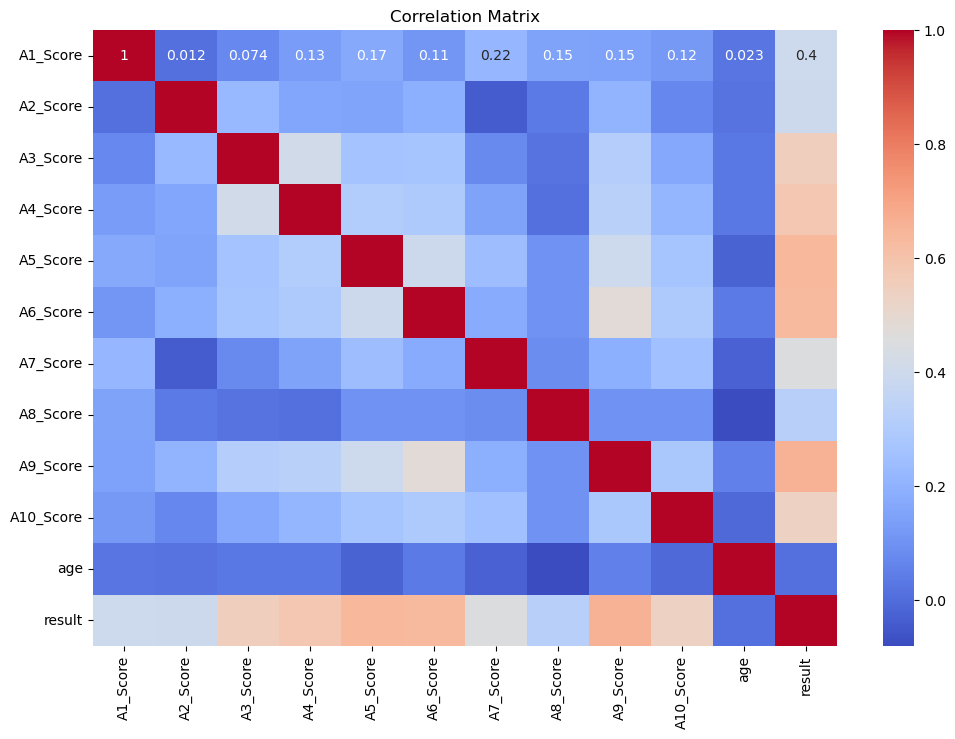

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


## **Outlier Detection**

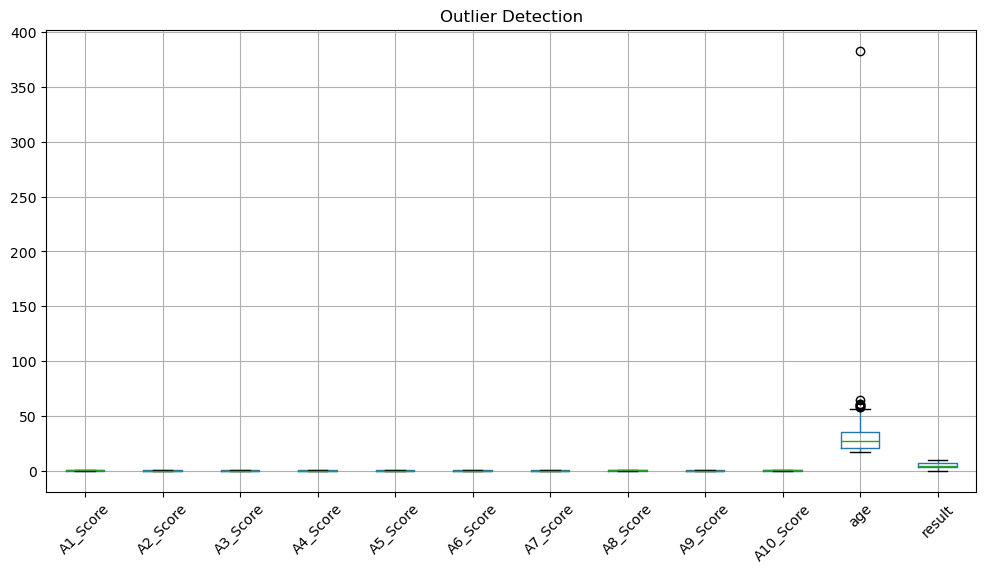

In [ ]:
plt.figure(figsize=(12,6))
df[numerical_cols].boxplot(rot=45)
plt.title("Outlier Detection")
plt.show()


## **Age Distribution**

/opt/anaconda3/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


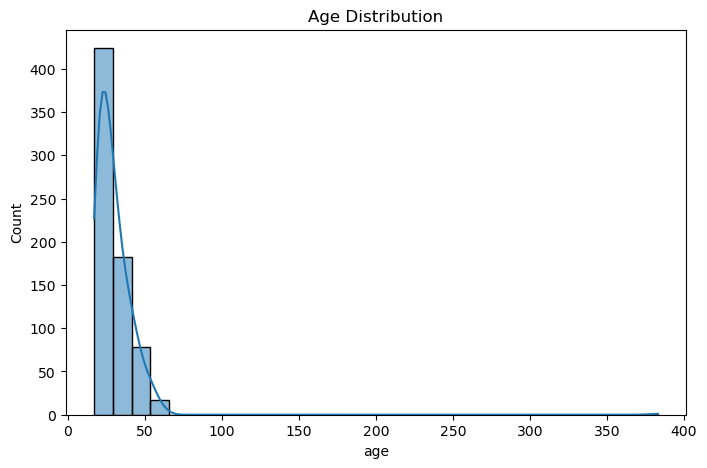

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


# **Separate Features & Target**

In [ ]:
X = df.drop('class', axis=1)
y = df['class']


## **Train–Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# **DATA PREPROCESSING**

## **Identify Column Types**

In [ ]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns


## **Handling Missing Values**

In [ ]:
# Imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Apply on TRAIN
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])

# Apply on TEST (no fit!)
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])


## **Categorial feature Encoding**

In [ ]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])


## **Encode Target Variable**

In [ ]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)


## **Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (optional but clean)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [ ]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jaundice,family_pdd,country_of_res,used_app_before,result,age_desc,relation,class
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,NaN,no,no,Egypt,no,2,'18 and more',NaN,NO


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize
log_reg = LogisticRegression()

# Training and timing
start_train = time.time()
log_reg.fit(X_train_scaled, y_train)
train_time_lr = time.time() - start_train

# Testing and timing
start_test = time.time()
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
test_time_lr = time.time() - start_test

print(f"Logistic Regression - Train Time: {train_time_lr:.4f}s, Test Time: {test_time_lr:.4f}s")
print(classification_report(y_test, y_pred_lr))

Logistic Regression - Train Time: 0.0061s, Test Time: 0.0014s
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        38

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



In [ ]:
from sklearn.svm import SVC

# Initialize (probability=True is required for ROC curves)
svm_model = SVC(kernel='linear', probability=True)

# Training
start_train = time.time()
svm_model.fit(X_train_scaled, y_train)
train_time_svm = time.time() - start_train

# Testing
start_test = time.time()
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
test_time_svm = time.time() - start_test

print(f"SVM - Train Time: {train_time_svm:.4f}s, Test Time: {test_time_svm:.4f}s")
print(classification_report(y_test, y_pred_svm))

SVM - Train Time: 0.0046s, Test Time: 0.0010s
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        38

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training
start_train = time.time()
rf_model.fit(X_train_scaled, y_train)
train_time_rf = time.time() - start_train

# Testing
start_test = time.time()
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
test_time_rf = time.time() - start_test

print(f"Random Forest - Train Time: {train_time_rf:.4f}s, Test Time: {test_time_rf:.4f}s")
print(classification_report(y_test, y_pred_rf))

Random Forest - Train Time: 0.0636s, Test Time: 0.0046s
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        38

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



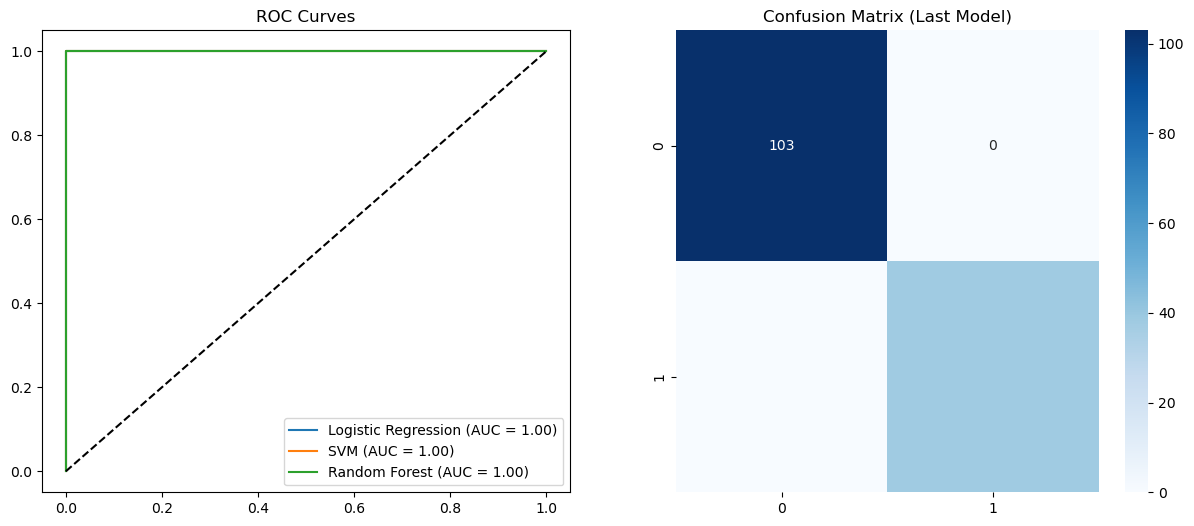

In [ ]:
def plot_results(models_data):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for name, y_prob, y_pred in models_data:
        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    axes[0].plot([0, 1], [0, 1], 'k--')
    axes[0].set_title('ROC Curves')
    axes[0].legend()

    # Confusion Matrix for the last model (as an example)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', ax=axes[1], cmap='Blues')
    axes[1].set_title(f'Confusion Matrix (Last Model)')
    plt.show()

# Run the visualization
results = [
    ('Logistic Regression', y_prob_lr, y_pred_lr),
    ('SVM', y_prob_svm, y_pred_svm),
    ('Random Forest', y_prob_rf, y_pred_rf)
]
plot_results(results)

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd

# Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_list = []

for name, model in models.items():
    # Perform cross-validation
    # We use X_train_scaled and y_train to keep the test set truly 'unseen'
    cv_results = cross_validate(model, X_train_scaled, y_train,
                                cv=skf, scoring=scoring,
                                return_train_score=False)

    # Store results
    cv_results_list.append({
        "Model": name,
        "Accuracy": cv_results['test_accuracy'].mean(),
        "Precision": cv_results['test_precision'].mean(),
        "Recall": cv_results['test_recall'].mean(),
        "F1-Score": cv_results['test_f1'].mean(),
        "Avg Train Time (s)": cv_results['fit_time'].mean()
    })

# Convert to DataFrame for a clean comparison table
cv_df = pd.DataFrame(cv_results_list)
print(cv_df)

                 Model  Accuracy  Precision  Recall  F1-Score  \
0  Logistic Regression       1.0        1.0     1.0       1.0   
1                  SVM       1.0        1.0     1.0       1.0   
2        Random Forest       1.0        1.0     1.0       1.0   

   Avg Train Time (s)  
0            0.001304  
1            0.002257  
2            0.039220  


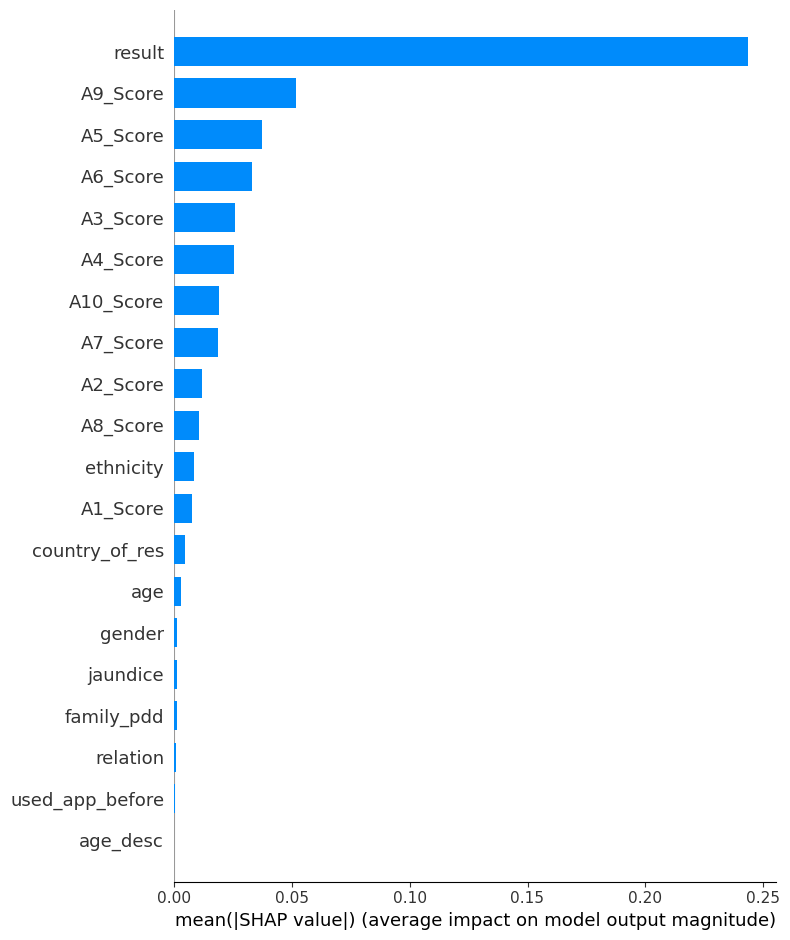

In [ ]:
import numpy as np

# 1. Calculate SHAP values
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# 2. Handle version-specific output shapes
# If shap_values is a list (older versions/certain settings), take the second element
# If it's a single numpy array, use it directly
if isinstance(shap_values, list):
    # For binary classification, index 1 is usually the "Positive/Yes" class
    correct_shap_values = shap_values[1]
else:
    correct_shap_values = shap_values

# 3. Check for the case where SHAP returns (samples, features, classes)
if len(correct_shap_values.shape) == 3:
    correct_shap_values = correct_shap_values[:, :, 1]

# 4. Now plot using the validated matrix
plt.figure(figsize=(10, 6))
shap.summary_plot(correct_shap_values, X_test_scaled, plot_type="bar")

In [ ]:
def check_bias(df_test, y_pred, column_name, privileged_value):
    # Create a temporary copy to avoid modifying original data
    results = df_test.copy()
    results['prediction'] = y_pred

    # Calculate selection rate (percentage of positive results) for each group
    groups = results.groupby(column_name)['prediction'].mean()

    priv_rate = groups[privileged_value]
    print(f"--- Bias Analysis for {column_name} ---")

    for val, rate in groups.items():
        di_ratio = rate / priv_rate if priv_rate > 0 else 0
        status = "FAIL" if di_ratio < 0.8 or di_ratio > 1.25 else "PASS"
        print(f"Group: {val:15} | Selection Rate: {rate:.2%} | DI Ratio: {di_ratio:.2f} | {status}")

# Usage: Compare Gender (Assuming 'm' is privileged based on historical data)
# Note: Ensure your X_test index matches your original dataframe index
X_test_with_meta = df.loc[X_test.index]
check_bias(X_test_with_meta, y_pred_rf, 'gender', 'm')

# Usage: Compare Ethnicity (Assuming 'White-European' as the reference group)
check_bias(X_test_with_meta, y_pred_rf, 'ethnicity', 'White-European')

--- Bias Analysis for gender ---
Group: f               | Selection Rate: 29.41% | DI Ratio: 1.19 | PASS
Group: m               | Selection Rate: 24.66% | DI Ratio: 1.00 | PASS
--- Bias Analysis for ethnicity ---
Group: 'Middle Eastern ' | Selection Rate: 16.67% | DI Ratio: 0.31 | FAIL
Group: 'South Asian'   | Selection Rate: 9.09% | DI Ratio: 0.17 | FAIL
Group: Asian           | Selection Rate: 13.79% | DI Ratio: 0.26 | FAIL
Group: Black           | Selection Rate: 50.00% | DI Ratio: 0.94 | PASS
Group: Hispanic        | Selection Rate: 0.00% | DI Ratio: 0.00 | FAIL
Group: Latino          | Selection Rate: 40.00% | DI Ratio: 0.76 | FAIL
Group: Others          | Selection Rate: 33.33% | DI Ratio: 0.63 | FAIL
Group: Pasifika        | Selection Rate: 0.00% | DI Ratio: 0.00 | FAIL
Group: Turkish         | Selection Rate: 0.00% | DI Ratio: 0.00 | FAIL
Group: White-European  | Selection Rate: 52.94% | DI Ratio: 1.00 | PASS


/opt/anaconda3/lib/python3.12/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


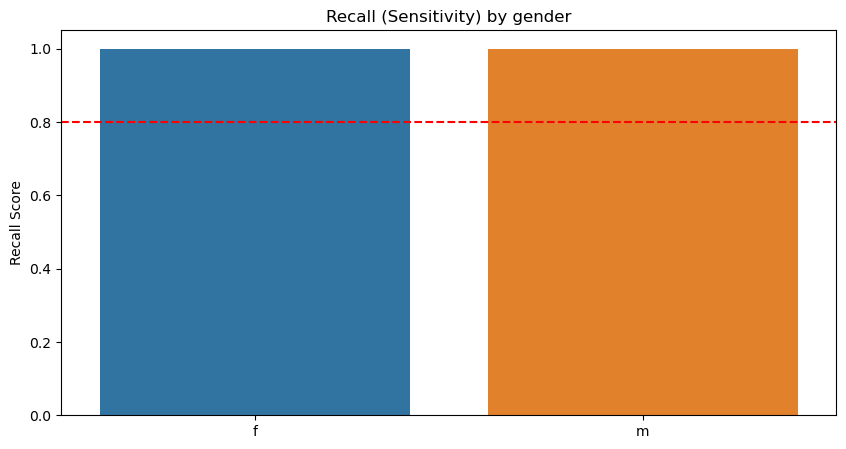

In [ ]:
from sklearn.metrics import recall_score
import seaborn as sns

def plot_group_recall(df_test, y_true, y_pred, column):
    group_recalls = {}
    for group in df_test[column].unique():
        mask = df_test[column] == group
        if mask.sum() > 0:
            group_recalls[group] = recall_score(y_true[mask], y_pred[mask])

    # Plotting
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(group_recalls.keys()), y=list(group_recalls.values()))
    plt.title(f'Recall (Sensitivity) by {column}')
    plt.ylabel('Recall Score')
    plt.axhline(0.8, color='red', linestyle='--') # Threshold line
    plt.show()

plot_group_recall(X_test_with_meta, y_test, y_pred_rf, 'gender')